In [9]:
import argparse
import os
import re
import fnmatch
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 24
plt.rcParams['axes.labelsize'] = 48
plt.rcParams['axes.titlesize'] = 48
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

In [10]:
actions = [
    "cartesian_position",
    "joint_position",
    "joint_velocity"
] 

In [11]:
use_prop = True

In [12]:
folder_path = "/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/"

In [13]:
action = actions[0]

In [14]:
file_paths = [
    os.path.join(folder_path, f"{action}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
    for i in range(15)
]
print(file_paths)

['/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_0.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_1.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_2.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_3.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_4.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_5.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_6.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_True_trial_7.pkl.csv',

In [15]:
dfs = []
for path in file_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Extract trial number from filename using regex
        match = re.search(r"trial_(\d+)", os.path.basename(path))
        trial = int(match.group(1)) if match else None
        df['trial'] = trial
        dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)
all_results

,t,success,grasped,has_collided,joint_jerks,proprioception,trial time,trial
0,0,False,False,False,2.808970,[-0.013 0.236 0.014 -2.112 -0.008 2.33 0....,NaN,0
1,1,False,False,False,2.808970,[-0.013 0.236 0.014 -2.112 -0.008 2.33 0....,NaN,0
2,2,False,False,False,24.360352,[-0.012 0.236 0.013 -2.113 -0.008 2.33 0....,NaN,0
3,3,False,False,False,31.879052,[-0.011 0.236 0.012 -2.113 -0.007 2.33 0....,NaN,0
4,4,False,False,False,19.912395,[-0.01 0.236 0.011 -2.114 -0.007 2.33 0....,NaN,0
...,...,...,...,...,...,...,...,...
12345,1484,False,False,False,7.356067,[ 0.4 0.707 -0.258 -1.85 0.211 2.381 0....,NaN,14
12346,1485,False,False,False,4.325153,[ 0.4 0.707 -0.258 -1.85 0.211 2.381 0....,NaN,14
12347,1486,False,False,False,3.008050,[ 0.4 0.707 -0.258 -1.85 0.211 2.38 0....,NaN,14
12348,1487,False,False,False,4.044461,[ 0.4 0.707 -0.258 -1.85 0.211 2.38 0....,NaN,14


In [16]:
# per-trial boolean: True if any success in trial
per_trial_success = all_results.groupby("trial")["success"].any()

n = per_trial_success.size
p = per_trial_success.mean()                # fraction in [0,1]
se_prop = np.sqrt(p * (1 - p) / n)          # binomial SE
ci_low, ci_high = p - 1.96*se_prop, p + 1.96*se_prop
print(f"n={n}, p={p:.3f}, SE={se_prop:.4f}, 95% CI=({ci_low:.3f},{ci_high:.3f})")

n=15, p=0.800, SE=0.1033, 95% CI=(0.598,1.002)


In [17]:
first_time = all_results.groupby("trial")["trial time"].apply(
    lambda s: s.dropna().iloc[0] if s.dropna().size > 0 else np.nan
).dropna().astype(float)
print(first_time)
n = len(first_time)
mean_time = first_time.mean()
se = first_time.std(ddof=1) / np.sqrt(n)
mean_time, se

trial
0     37.133804
1     29.754415
2     26.769756
3     27.899514
4     38.566594
5     26.918132
6     25.262905
7     60.000916
8     23.157839
9     25.852949
10    22.198865
11    23.872088
12    60.005618
13    34.071026
14    60.037780
Name: trial time, dtype: float64


(np.float64(34.76681334177653), np.float64(3.5936058619101865))

In [41]:
trial_stats = all_results.groupby('trial').agg(
    num_collisions=('has_collided', 'sum'),
    trial_length=('has_collided', 'count')
)
trial_stats['trial_collision_rate'] = trial_stats['num_collisions'] / trial_stats['trial_length']
trial_stats

,num_collisions,trial_length,trial_collision_rate
trial,,,
0,0,192,0.0
1,0,171,0.0
2,0,180,0.0
3,0,168,0.0
4,0,15,0.0
5,0,350,0.0
6,0,199,0.0
7,0,183,0.0
8,0,199,0.0


In [42]:
results = {}
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(15)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        success_rate = all_results.groupby('trial')['success'].any().mean() * 100
        
        results[act] = success_rate
    else:
        results[act] = None
# Show bar plot of success rates for each action
results_df = pd.DataFrame(list(results.items()), columns=['action', 'success_rate'])
results_df.to_csv('success_rates_by_action.csv', index=False)

<Figure size 800x600 with 0 Axes>

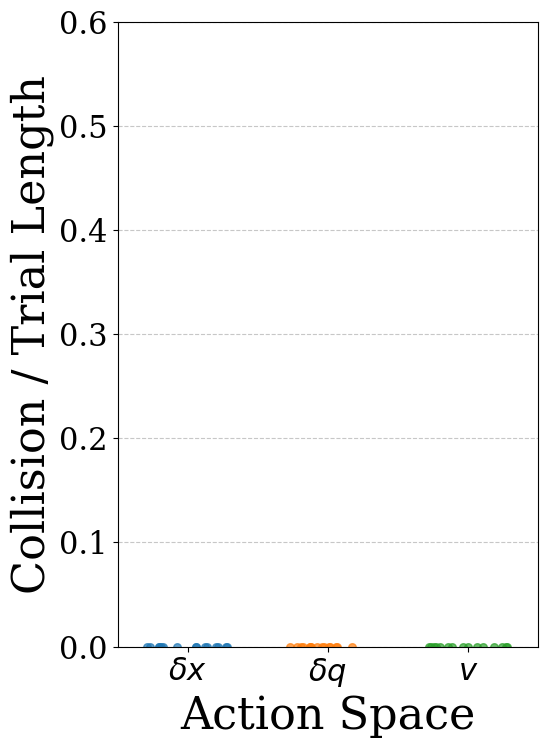

In [45]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(15)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            num_collisions=('has_collided', 'sum'),
            trial_length=('has_collided', 'count')
        )
        trial_stats['trial_collision_rate'] = (trial_stats['num_collisions'] / trial_stats['trial_length'])
        collision_rates.append(trial_stats['trial_collision_rate'].dropna())
        labels.append(act)
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.figure(figsize=(6, 8))
np.random.seed(42)  # For reproducibility
for i, rates in enumerate(collision_rates):
    y = rates.values
    # Add a small random jitter to x to avoid overlap
    x = np.full_like(y, i, dtype=float) + np.random.uniform(-0.3, 0.3, size=len(y))
    plt.scatter(x, y, alpha=0.7, s=30, label=labels[i])
plt.xticks(range(len(labels)), labels, fontsize=22)
plt.ylabel('Collision / Trial Length', fontsize=32)
plt.xlabel('Action Space', fontsize=32)
# plt.title('Average Collision Rate Across Trials', fontsize=20)
plt.yticks(fontsize=22)
plt.ylim(0, 0.6)
plt.xlim(-0.5, len(labels)-0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"collision_rate_prop_{use_prop}_dotplot.pdf")
plt.show()



<Figure size 800x600 with 0 Axes>

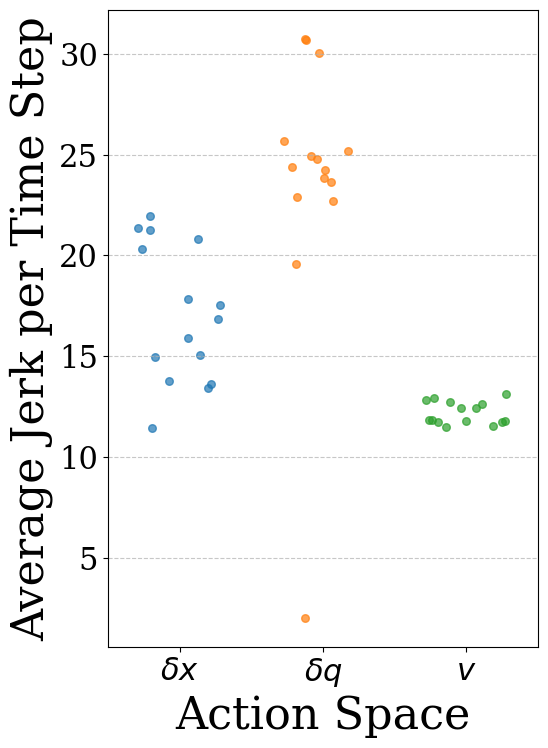

In [44]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(15)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            jerks=('joint_jerks', 'mean')
        )
        collision_rates.append(trial_stats['jerks'].dropna())
        labels.append(act)
# To use LaTeX in matplotlib labels, wrap your label strings with r"$...$"
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.figure(figsize=(6, 8))
np.random.seed(42)  # For reproducibility
for i, rates in enumerate(collision_rates):
    y = rates.values
    # Add a small random jitter to x to avoid overlap
    x = np.full_like(y, i, dtype=float) + np.random.uniform(-0.3, 0.3, size=len(y))
    plt.scatter(x, y, alpha=0.7, s=30, label=labels[i])
plt.xticks(range(len(labels)), labels, fontsize=22)
plt.ylabel('Average Jerk per Time Step', fontsize=32)
plt.xlabel('Action Space', fontsize=32)
# plt.title('Average Collision Rate Across Trials', fontsize=20)
plt.yticks(fontsize=22)
plt.xlim(-0.5, len(labels)-0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"jerk_prop_{use_prop}_dotplot.pdf")
plt.show()